# 05 - Análises Segmentadas

Estima 13 modelos OLS em subamostras temáticas, com a mesma especificação
do nb 04 (Y = `ConvertedCompYearly`; X = YearsCode + 20 dummies de
linguagem + controles de país/área/formação), omitindo em cada recorte a
variável que o define.

Recortes:
- **Por área:** backend, frontend, fullstack, mobile (4 modelos)
- **Por país:** USA, Alemanha, UK, França, Índia, Brasil (6 modelos)
- **Por experiência:** júnior (0-4 anos), pleno (5-7), sênior (8+) (3 modelos)

Comparação entre subamostras: gráfico de coeficientes com IC 95%.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

# Carrega o dataset limpo
df = pd.read_csv('../data/processed/df_limpo.csv')

# Recria EdLevel_modelo (não persistida no CSV; criada em runtime no nb 04)
# "Outros" reagrupado em "Superior incompleto" por baixa frequência (0,83%)
df['EdLevel_modelo'] = df['EdLevel_agrupado'].replace(
    {'Outros': 'Superior incompleto'}
)

# Sanity check
print(f"n total: {len(df):,}")
print(f"colunas lang_*: {sum(c.startswith('lang_') for c in df.columns)}")
print(f"\nDevType_agrupado:\n{df['DevType_agrupado'].value_counts()}")
print(f"\nEdLevel_modelo:\n{df['EdLevel_modelo'].value_counts()}")

n total: 14,171
colunas lang_*: 20

DevType_agrupado:
DevType_agrupado
fullstack    6467
backend      5050
data_ml      1111
frontend      917
mobile        626
Name: count, dtype: int64

EdLevel_modelo:
EdLevel_modelo
Bacharelado            6608
Mestrado               4106
Superior incompleto    1752
Médio                   622
Doutorado               542
Tecnólogo               482
Fundamental              59
Name: count, dtype: int64


## 2. Função reutilizável `estimar_modelo`

Encapsula a lógica do nb 04 (matriz de design + OLS + extração de
coeficientes com IC 95%). O parâmetro `controles_categoricos` permite
omitir a variável que define o recorte (ex: ao rodar só na subamostra
backend, omitir `DevType_agrupado` porque ela vira constante).

In [2]:
def estimar_modelo(df_sub, nome, controles_categoricos=None, incluir_years_code=True):
    """
    Estima OLS com Y = ConvertedCompYearly na subamostra `df_sub`.

    Parâmetros
    ----------
    df_sub : DataFrame
        Subamostra já filtrada.
    nome : str
        Identificador (ex: 'backend', 'Brasil', 'junior').
    controles_categoricos : list, opcional
        Categóricas a incluir como dummies. Default = todas três do nb 04.
        Em recortes que fixam uma categoria, omita-la desta lista.

    Retorna
    -------
    dict com: nome, n, k, r2, r2_aj, f, p_f, modelo, coefs
    """
    if controles_categoricos is None:
        controles_categoricos = ['Country_agrupado', 'DevType_agrupado', 'EdLevel_modelo']

    baselines = {
        'Country_agrupado': 'USA',
        'DevType_agrupado': 'backend',
        'EdLevel_modelo':   'Bacharelado',
    }

    cols_lang = [c for c in df_sub.columns if c.startswith('lang_')]
    X_partes = []
    if incluir_years_code:
        X_partes.append(df_sub[['YearsCode']].copy())
    X_partes.append(df_sub[cols_lang].copy())

    # Dummies dos controles categóricos com baseline removida
    for col in controles_categoricos:
        dummies = pd.get_dummies(df_sub[col], prefix=col, drop_first=False)
        col_baseline = f"{col}_{baselines[col]}"
        if col_baseline in dummies.columns:
            dummies = dummies.drop(columns=[col_baseline])
        X_partes.append(dummies)

    X = pd.concat(X_partes, axis=1).astype(float)
    X = sm.add_constant(X)
    y = df_sub['ConvertedCompYearly'].astype(float)

    modelo = sm.OLS(y, X).fit()

    # Tabela de coeficientes + IC 95% + p-valor
    ic = modelo.conf_int(alpha=0.05)
    ic.columns = ['ic_inf', 'ic_sup']
    coefs = pd.DataFrame({
        'coef':    modelo.params,
        'ic_inf':  ic['ic_inf'],
        'ic_sup':  ic['ic_sup'],
        'p_valor': modelo.pvalues,
    })

    return {
        'nome':   nome,
        'n':      int(modelo.nobs),
        'k':      int(modelo.df_model),
        'r2':     modelo.rsquared,
        'r2_aj':  modelo.rsquared_adj,
        'f':      modelo.fvalue,
        'p_f':    modelo.f_pvalue,
        'modelo': modelo,
        'coefs':  coefs,
    }

## 3. Recorte 1 - Por área de atuação

Esta seção responde à pergunta: **as linguagens que pagam mais são as mesmas em todas as áreas, ou cada área tem suas linguagens "mais valorizadas"?** Para responder, separamos a base em quatro grupos (backend, frontend, fullstack e mobile) e estimamos o mesmo modelo do nb 04 dentro de cada grupo. Ao comparar os coeficientes, conseguimos ver se uma linguagem que paga bem no backend continua pagando bem no frontend, por exemplo. A área `data_ml` (1.111 desenvolvedores) ficou de fora porque não estava entre as áreas listadas na pergunta original do trabalho.

In [3]:
areas = ['backend', 'frontend', 'fullstack', 'mobile']
resultados_devtype = {}

for area in areas:
    df_sub = df[df['DevType_agrupado'] == area].copy()
    res = estimar_modelo(
        df_sub,
        nome=area,
        controles_categoricos=['Country_agrupado', 'EdLevel_modelo'],
    )
    resultados_devtype[area] = res
    print(f"{area:10s} | n={res['n']:5,} | k={res['k']:2d} | "
          f"R²={res['r2']:.3f} | F={res['f']:6.2f} | p(F)={res['p_f']:.2e}")

backend    | n=5,050 | k=37 | R²=0.439 | F=106.11 | p(F)=0.00e+00
frontend   | n=  917 | k=37 | R²=0.492 | F= 23.03 | p(F)=3.15e-104
fullstack  | n=6,467 | k=37 | R²=0.458 | F=146.65 | p(F)=0.00e+00
mobile     | n=  626 | k=37 | R²=0.537 | F= 18.41 | p(F)=2.08e-75


### 3.1 Tabela comparativa: o salário extra por linguagem em cada área

A tabela abaixo mostra, para cada linguagem, **quanto a mais (ou a
menos) em USD anuais um desenvolvedor ganha quando declara usá-la**,
em comparação com alguém de perfil semelhante (mesma experiência,
mesmo país, mesma formação) que não a utiliza.

Os asteriscos indicam o nível de confiança estatística do resultado:
**`**`** significa alta confiança (probabilidade menor que 1% de o
efeito ser fruto do acaso) e **`*`** confiança boa (menor que 5%).
Valores sem asterisco devem ser lidos com cautela.

In [4]:
# Monta tabela larga: linhas = linguagens, colunas = áreas
linguagens = [c for c in df.columns if c.startswith('lang_')]

linhas = []
for lang in linguagens:
    linha = {'linguagem': lang.replace('lang_', '')}
    for area in areas:
        coefs = resultados_devtype[area]['coefs']
        if lang in coefs.index:
            coef = coefs.loc[lang, 'coef']
            p = coefs.loc[lang, 'p_valor']
            marca = '**' if p < 0.01 else ('*' if p < 0.05 else '')
            linha[area] = f"{coef:+,.0f}{marca}"
        else:
            linha[area] = '—'
    linhas.append(linha)

tabela_devtype = pd.DataFrame(linhas).set_index('linguagem')
print(tabela_devtype.to_string())

# Salva
tabela_devtype.to_csv('../output/tables/05_coefs_linguagens_por_devtype.csv')
print("\nSalvo: output/tables/05_coefs_linguagens_por_devtype.csv")

              backend   frontend  fullstack     mobile
linguagem                                             
JavaScript     -2,743     -1,151     -3,408     +3,381
HTML_CSS     -8,359**     +3,994   -7,347**    -10,904
SQL            -3,140     -5,404   -3,785**     -4,377
Python       +4,653**     -3,663       +768     -1,538
TypeScript   +8,877**   +10,693*  +13,048**       -802
Bash_Shell   +4,604**     +2,924   +3,798**  +13,605**
CSharp       -8,062**     -2,513   -5,163**   -13,495*
Java             -963     +5,859       -782     +1,179
PowerShell   -6,566**   -13,489*       -847     -9,525
CPlusPlus        -202    -10,466     -2,066     +7,535
PHP         -10,791**  -13,081**  -15,110**    -11,061
Go          +16,533**    +10,638   +9,815**    +15,164
C            -8,597**       +342   -6,252**     +6,284
Rust         +8,925**     +1,208    +4,172*    +19,281
Kotlin        +6,494*     +1,850   +6,483**     +2,482
Lua              +105     +5,000     +1,609    -12,120
Ruby      

### 3.2 Gráfico de coeficientes com IC 95%

Cada linha do gráfico é uma linguagem de programação. Cada cor representa
uma área de atuação (backend, frontend, fullstack, mobile). O ponto mostra
**quanto a mais (ou a menos) em USD um desenvolvedor ganha quando usa
aquela linguagem**, comparado a alguém com perfil semelhante que não a
usa, dentro daquela área.

A barra horizontal ao redor do ponto é a **margem de incerteza** do
resultado: quando ela cruza a linha do zero, não dá para afirmar com
segurança que a linguagem aumenta ou reduz o salário naquela área.
Pontos com barras curtas indicam estimativas mais confiáveis; barras
longas (geralmente em mobile, por ter menos respondentes) pedem cautela
na leitura.

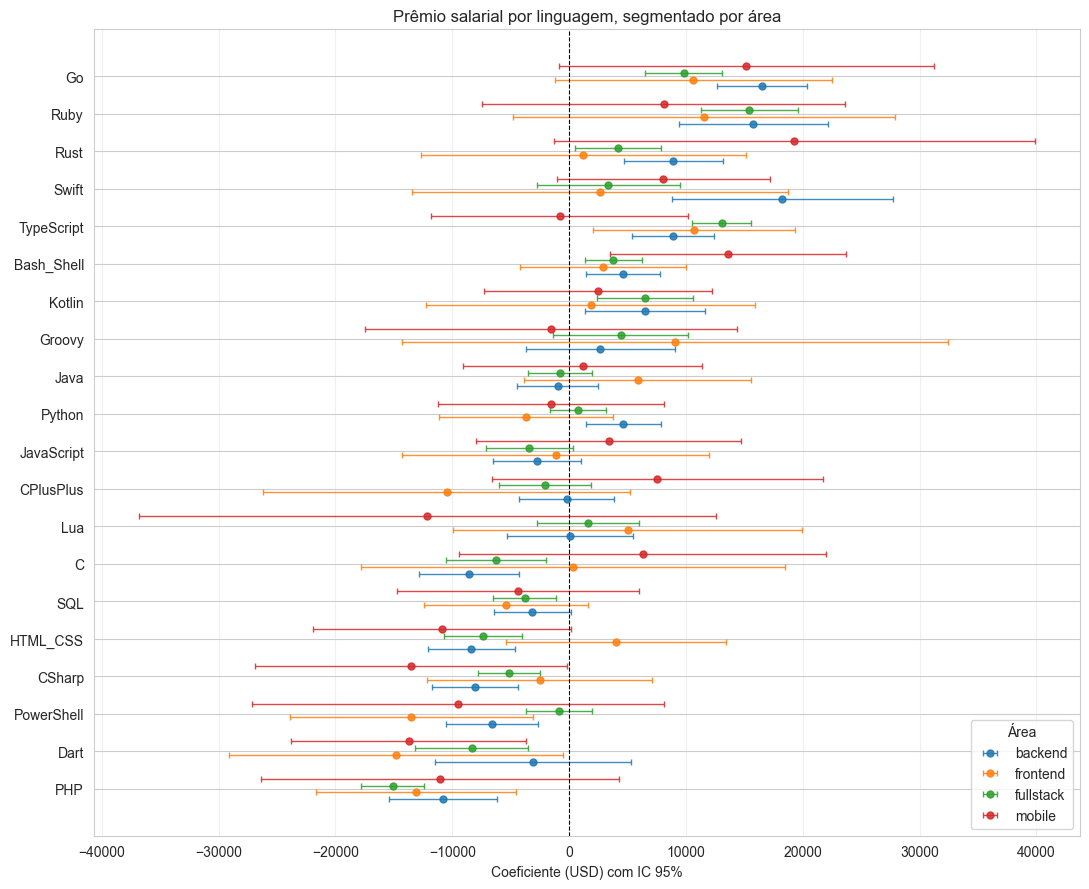

Salvo: output/figures/05_coefs_linguagens_por_devtype.png


In [5]:
# Monta DataFrame longo: uma linha por (linguagem, area)
linhas = []
for area in areas:
    coefs = resultados_devtype[area]['coefs']
    for lang in linguagens:
        if lang in coefs.index:
            linhas.append({
                'linguagem': lang.replace('lang_', ''),
                'area':      area,
                'coef':      coefs.loc[lang, 'coef'],
                'ic_inf':    coefs.loc[lang, 'ic_inf'],
                'ic_sup':    coefs.loc[lang, 'ic_sup'],
            })

df_plot = pd.DataFrame(linhas)

# Ordena linguagens pelo coef médio entre áreas (do maior pro menor)
ordem = (df_plot.groupby('linguagem')['coef']
         .mean().sort_values(ascending=True).index.tolist())

fig, ax = plt.subplots(figsize=(11, 9))
cores = {'backend': '#1f77b4', 'frontend': '#ff7f0e',
         'fullstack': '#2ca02c', 'mobile': '#d62728'}
offsets = {'backend': -0.27, 'frontend': -0.09,
           'fullstack': +0.09, 'mobile': +0.27}

for area in areas:
    sub = df_plot[df_plot['area'] == area].set_index('linguagem').loc[ordem]
    y = np.arange(len(ordem)) + offsets[area]
    ax.errorbar(
        sub['coef'], y,
        xerr=[sub['coef'] - sub['ic_inf'], sub['ic_sup'] - sub['coef']],
        fmt='o', color=cores[area], label=area, markersize=5,
        capsize=2, elinewidth=1, alpha=0.85,
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(np.arange(len(ordem)))
ax.set_yticklabels(ordem)
ax.set_xlabel('Coeficiente (USD) com IC 95%')
ax.set_title('Prêmio salarial por linguagem, segmentado por área')
ax.legend(title='Área', loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/figures/05_coefs_linguagens_por_devtype.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Salvo: output/figures/05_coefs_linguagens_por_devtype.png")

### 3.3 Síntese do Recorte 1

A análise por área mostra que existem **duas histórias diferentes** nas
linguagens estudadas:

**Linguagens com prêmio consistente em todas as áreas:** Go, Ruby,
Rust, Swift, TypeScript, Bash/Shell e Kotlin aparecem com coeficiente
positivo nas quatro áreas. Indica que o valor de mercado dessas
linguagens é menos dependente da especialização do desenvolvedor.

**Linguagens com penalidade consistente:** PHP, Dart, PowerShell,
CSharp e HTML/CSS apresentam coeficiente negativo nas quatro áreas.
Importante notar que isso **não significa que essas linguagens "não
prestem"**. Significa que, controlando pelos demais fatores, quem as
declara recebe em média menos do que quem não as declara. É um sinal
do mercado, não da qualidade técnica da linguagem.

**Linguagens que mudam de comportamento:** JavaScript, Python, Java e
C++ trocam de sinal entre áreas. O Python, por exemplo, aparece com
prêmio positivo no backend e penalidade no frontend. Coerente com o
fato de Python ser uma linguagem-chave em backend e ciência de dados,
mas pouco usada como diferencial no frontend.

**Sobre a área mobile:** as estimativas mobile têm barras de incerteza
maiores devido ao tamanho menor da subamostra (626 desenvolvedores).
Vários resultados nesse grupo cruzam o zero e devem ser interpretados
como "não foi possível afirmar com segurança", não como "efeito nulo".

## 4. Recorte 2 - Por país

Esta seção responde à pergunta: **as linguagens que pagam mais são as
mesmas em todos os países, ou cada mercado valoriza linguagens
diferentes?**

Para responder, separamos a base em seis grupos por país e estimamos o
mesmo modelo dentro de cada grupo. Os países foram escolhidos por
combinar volume de respondentes e relevância para a pergunta de
pesquisa: USA, Alemanha, Reino Unido, França e Índia (cinco maiores da
amostra) mais o Brasil (foco da nossa análise comparativa).

Importante: este recorte **não compara o nível salarial entre países**
(isso já foi mostrado no nb 04 — ver os coeficientes de `Country`).
Aqui comparamos o **efeito relativo de cada linguagem dentro de cada
país**.

In [6]:
paises = ['United States of America', 'Germany',
          'United Kingdom of Great Britain and Northern Ireland',
          'France', 'India', 'Brazil']

# Rótulos curtos para gráficos e tabelas
rotulos = {
    'United States of America': 'USA',
    'Germany': 'Alemanha',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
    'France': 'França',
    'India': 'Índia',
    'Brazil': 'Brasil',
}

resultados_pais = {}

for pais in paises:
    df_sub = df[df['Country'] == pais].copy()
    rotulo = rotulos[pais]
    res = estimar_modelo(
        df_sub,
        nome=rotulo,
        controles_categoricos=['DevType_agrupado', 'EdLevel_modelo'],
    )
    resultados_pais[rotulo] = res
    print(f"{rotulo:10s} | n={res['n']:4,} | k={res['k']:2d} | "
          f"R²={res['r2']:.3f} | F={res['f']:6.2f} | p(F)={res['p_f']:.2e}")

USA        | n=3,049 | k=31 | R²=0.191 | F= 22.91 | p(F)=4.97e-115
Alemanha   | n=1,236 | k=31 | R²=0.205 | F= 10.04 | p(F)=6.67e-42
UK         | n= 936 | k=31 | R²=0.196 | F=  7.09 | p(F)=1.40e-26
França     | n= 607 | k=31 | R²=0.198 | F=  4.58 | p(F)=4.24e-14
Índia      | n= 637 | k=31 | R²=0.164 | F=  3.83 | p(F)=6.52e-11
Brasil     | n= 381 | k=31 | R²=0.227 | F=  3.30 | p(F)=3.52e-08


### 4.1 Tabela comparativa: o salário extra por linguagem em cada país

Mesma leitura da tabela anterior, agora com seis colunas (uma por
país). Asteriscos indicam confiança estatística (** = p<0,01,
* = p<0,05).

In [7]:
paises_rot = ['USA', 'Alemanha', 'UK', 'França', 'Índia', 'Brasil']

linhas = []
for lang in linguagens:
    linha = {'linguagem': lang.replace('lang_', '')}
    for rotulo in paises_rot:
        coefs = resultados_pais[rotulo]['coefs']
        if lang in coefs.index:
            coef = coefs.loc[lang, 'coef']
            p = coefs.loc[lang, 'p_valor']
            marca = '**' if p < 0.01 else ('*' if p < 0.05 else '')
            linha[rotulo] = f"{coef:+,.0f}{marca}"
        else:
            linha[rotulo] = '—'
    linhas.append(linha)

tabela_pais = pd.DataFrame(linhas).set_index('linguagem')
print(tabela_pais.to_string())

tabela_pais.to_csv('../output/tables/05_coefs_linguagens_por_pais.csv')
print("\nSalvo: output/tables/05_coefs_linguagens_por_pais.csv")

                  USA   Alemanha         UK     França     Índia     Brasil
linguagem                                                                  
JavaScript     -4,915       +790     -8,443     +2,711    -5,065     -9,212
HTML_CSS    -14,658**     -5,225     -4,475     -8,016      +330     +2,428
SQL            -2,121     +2,351     -4,657     +6,612  -8,207**       -618
Python        +6,499*       +632     +4,727     -3,253    +1,652     -1,290
TypeScript  +18,527**     +3,792  +11,211**   +9,868**    +2,637     +7,175
Bash_Shell     +3,080     +2,150     +5,838     +3,269   +6,401*  +10,384**
CSharp      -13,817**   -6,925**  -13,385**       -107    +3,120     -1,576
Java           +2,800   -7,373**     +4,712    -8,146*    +1,226     -7,166
PowerShell   -9,814**     -1,793     -5,525     -8,313   -8,054*     -2,900
CPlusPlus      +2,854     -2,426     +2,463     -3,383    +4,510     -7,013
PHP         -25,648**  -11,247**  -21,273**  -10,353**   -7,667*   -10,218*
Go          

### 4.2 Gráfico de coeficientes com IC 95%

Cada linha é uma linguagem. Cada cor é um país. O ponto mostra o
salário extra (em USD) associado a usar aquela linguagem dentro do
país, comparado a um desenvolvedor de perfil semelhante naquele mesmo
país que não a utiliza.

A leitura é **interna a cada país**: um ponto positivo no Brasil e um
ponto positivo nos EUA não significam o mesmo valor absoluto — o
salário-base brasileiro é muito menor. O que se compara é se a
linguagem **adiciona** mais ou menos valor naquele mercado.

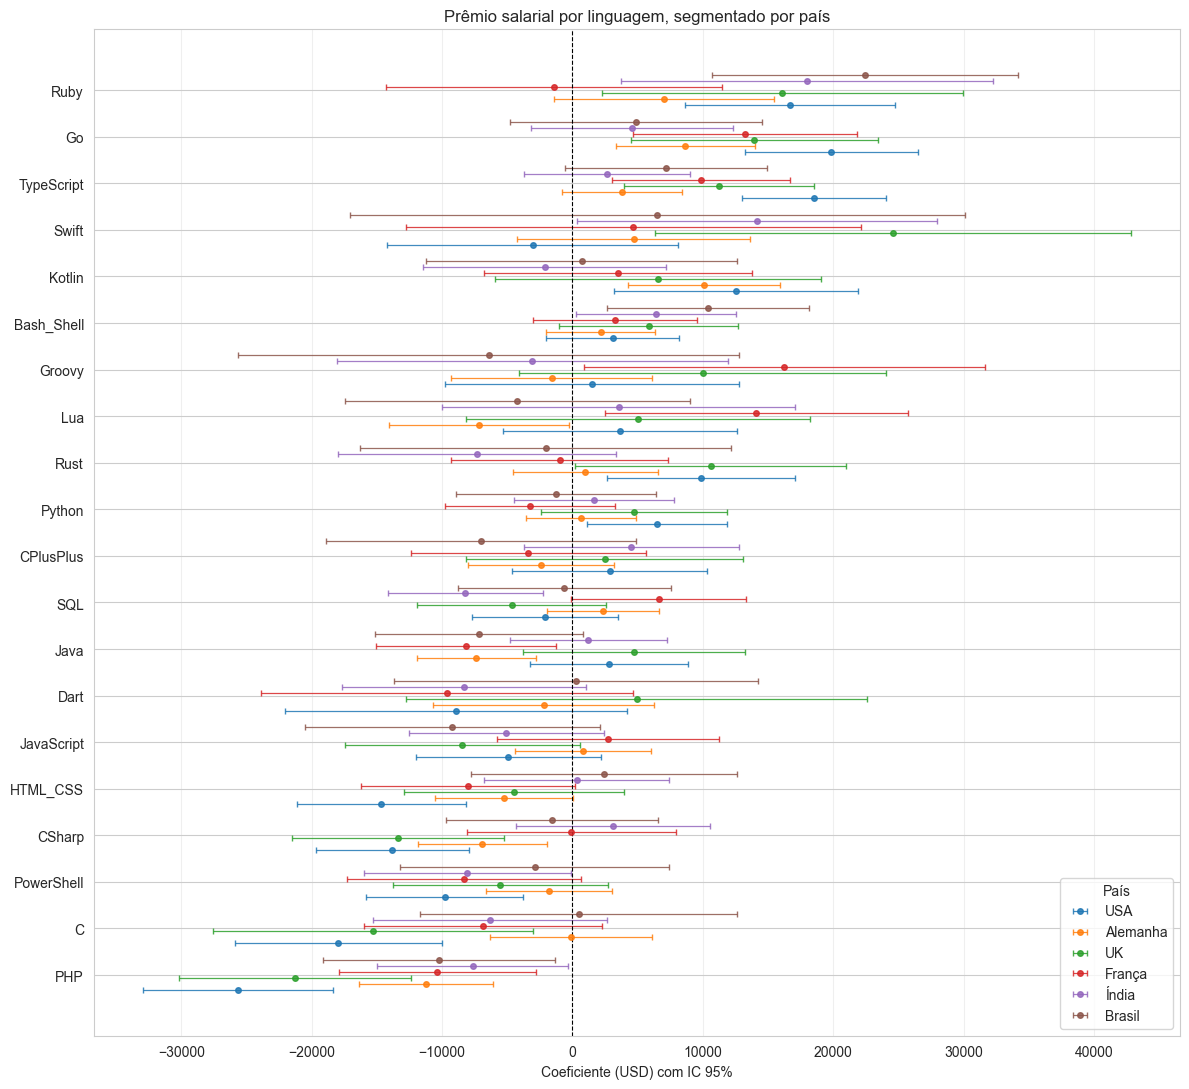

Salvo: output/figures/05_coefs_linguagens_por_pais.png


In [8]:
linhas = []
for rotulo in paises_rot:
    coefs = resultados_pais[rotulo]['coefs']
    for lang in linguagens:
        if lang in coefs.index:
            linhas.append({
                'linguagem': lang.replace('lang_', ''),
                'pais':      rotulo,
                'coef':      coefs.loc[lang, 'coef'],
                'ic_inf':    coefs.loc[lang, 'ic_inf'],
                'ic_sup':    coefs.loc[lang, 'ic_sup'],
            })

df_plot = pd.DataFrame(linhas)

# Ordena pelo coef médio entre países
ordem = (df_plot.groupby('linguagem')['coef']
         .mean().sort_values(ascending=True).index.tolist())

fig, ax = plt.subplots(figsize=(12, 11))
cores_pais = {
    'USA':      '#1f77b4',
    'Alemanha': '#ff7f0e',
    'UK':       '#2ca02c',
    'França':   '#d62728',
    'Índia':    '#9467bd',
    'Brasil':   '#8c564b',
}
offsets = {p: o for p, o in zip(
    paises_rot, np.linspace(-0.32, 0.32, len(paises_rot))
)}

for rotulo in paises_rot:
    sub = df_plot[df_plot['pais'] == rotulo].set_index('linguagem').loc[ordem]
    y = np.arange(len(ordem)) + offsets[rotulo]
    ax.errorbar(
        sub['coef'], y,
        xerr=[sub['coef'] - sub['ic_inf'], sub['ic_sup'] - sub['coef']],
        fmt='o', color=cores_pais[rotulo], label=rotulo, markersize=4,
        capsize=2, elinewidth=0.9, alpha=0.85,
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(np.arange(len(ordem)))
ax.set_yticklabels(ordem)
ax.set_xlabel('Coeficiente (USD) com IC 95%')
ax.set_title('Prêmio salarial por linguagem, segmentado por país')
ax.legend(title='País', loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/figures/05_coefs_linguagens_por_pais.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Salvo: output/figures/05_coefs_linguagens_por_pais.png")

### 4.3 Síntese do Recorte 2

**Como ler os valores:** os números mostram a **diferença salarial em
USD** associada ao uso de cada linguagem, dentro de cada país. Por
exemplo, o valor +22.436 do Ruby no Brasil significa que, comparando
dois desenvolvedores brasileiros com **mesma experiência, mesma área
e mesma formação**, aquele que declara usar Ruby ganha em média USD
22.436 a mais por ano. Não é o salário em si — é o adicional (ou
desconto) associado à linguagem.

Importante: valores negativos **não significam que a pessoa ganha
salário negativo** — significam apenas que, mantendo o resto igual,
quem declara aquela linguagem ganha menos que quem não declara.
Tipicamente isso reflete o perfil de vagas em que a linguagem é mais
usada (legado, sites menores, manutenção), não a qualidade da
linguagem em si.

**Linguagens com prêmio consistente entre países:** TypeScript, Go,
Ruby, Bash/Shell e Kotlin aparecem com coeficiente positivo na
maioria dos seis países analisados. Indica que são linguagens
valorizadas globalmente, não apenas em mercados específicos.

**Linguagens com penalidade consistente:** PHP e PowerShell aparecem
com coeficiente negativo em todos os seis países. Reforça o padrão
já observado na análise por área de atuação.

**Particularidades do Brasil:**
- **Ruby tem o maior prêmio entre os seis países analisados**
  (+USD 22.436), seguido por Índia e USA.
- **Bash/Shell também tem seu maior prêmio no Brasil** (+USD 10.384),
  sugerindo valorização de habilidades de automação e
  infraestrutura no mercado local.
- **JavaScript apresenta a maior penalidade entre os seis países**
  (-USD 9.212), comportamento oposto ao observado em mercados como
  França e Alemanha.

**Cuidado na comparação entre países:** os coeficientes são lidos
**dentro** de cada país. Um Ruby +22k no Brasil não significa que um
desenvolvedor brasileiro de Ruby ganha mais que um americano de Ruby
em termos absolutos — significa que, dentro do mercado brasileiro,
declarar Ruby está associado a um adicional proporcionalmente maior
do que declarar Ruby dentro do mercado americano.

**Limitação importante:** correlação não é causalidade. "Aprender
Ruby" não vai automaticamente aumentar o salário de um
desenvolvedor — o coeficiente reflete que **o perfil de quem declara
Ruby** (senioridade, tipo de empresa, vaga) está associado a salários
mais altos no Brasil, não que a linguagem por si só cause o aumento.

## 5. Recorte 3 - Por nível de experiência

Esta seção responde à pergunta: **as linguagens que pagam mais para
quem está começando são as mesmas que pagam mais para quem é
experiente?**

Para responder, separamos a base em três grupos de senioridade com
base na coluna `YearsCode` (anos totais programando, incluindo
aprendizado):

- **Júnior:** até 4 anos de código (≤ 4)
- **Pleno:** entre 5 e 7 anos
- **Sênior:** 8 anos ou mais

Os cortes seguem a convenção do mercado brasileiro de tecnologia.
Estimamos o mesmo modelo dentro de cada grupo, omitindo `YearsCode`
dos controles (vira pouco informativo dentro de cada faixa).

In [9]:
def classifica_nivel(anos):
    if anos <= 4:
        return 'junior'
    elif anos <= 7:
        return 'pleno'
    else:
        return 'senior'

df['nivel'] = df['YearsCode'].apply(classifica_nivel)

print("Distribuição por nível:")
print(df['nivel'].value_counts())
print()

niveis = ['junior', 'pleno', 'senior']
resultados_nivel = {}

for nivel in niveis:
    df_sub = df[df['nivel'] == nivel].copy()
    res = estimar_modelo(
        df_sub,
        nome=nivel,
        controles_categoricos=['Country_agrupado', 'DevType_agrupado', 'EdLevel_modelo'],
        incluir_years_code=False,
    )
    resultados_nivel[nivel] = res
    print(f"{nivel:8s} | n={res['n']:5,} | k={res['k']:2d} | "
          f"R²={res['r2']:.3f} | F={res['f']:6.2f} | p(F)={res['p_f']:.2e}")

Distribuição por nível:
nivel
senior    12081
pleno      1530
junior      560
Name: count, dtype: int64

junior   | n=  560 | k=40 | R²=0.463 | F= 11.17 | p(F)=6.17e-48
pleno    | n=1,530 | k=40 | R²=0.345 | F= 19.58 | p(F)=1.44e-108
senior   | n=12,081 | k=40 | R²=0.390 | F=192.23 | p(F)=0.00e+00


### 5.1 Tabela comparativa: o salário extra por linguagem em cada nível

Mesma leitura: cada valor é o **adicional em USD** associado a usar a
linguagem, comparando dois desenvolvedores do mesmo nível com perfis
semelhantes em país, área e formação. Asteriscos indicam confiança
estatística (** = p<0,01, * = p<0,05).

In [10]:
linhas = []
for lang in linguagens:
    linha = {'linguagem': lang.replace('lang_', '')}
    for nivel in niveis:
        coefs = resultados_nivel[nivel]['coefs']
        if lang in coefs.index:
            coef = coefs.loc[lang, 'coef']
            p = coefs.loc[lang, 'p_valor']
            marca = '**' if p < 0.01 else ('*' if p < 0.05 else '')
            linha[nivel] = f"{coef:+,.0f}{marca}"
        else:
            linha[nivel] = '—'
    linhas.append(linha)

tabela_nivel = pd.DataFrame(linhas).set_index('linguagem')
print(tabela_nivel.to_string())

tabela_nivel.to_csv('../output/tables/05_coefs_linguagens_por_nivel.csv')
print("\nSalvo: output/tables/05_coefs_linguagens_por_nivel.csv")

               junior      pleno     senior
linguagem                                  
JavaScript       +878    -6,055*     -1,886
HTML_CSS       +1,565     -1,462   -8,089**
SQL            -1,473     -2,456     -1,978
Python         -2,668     +1,980        -89
TypeScript     -4,623   +6,787**   +8,637**
Bash_Shell     +2,669   +5,861**   +5,634**
CSharp         +1,167     -1,528   -6,484**
Java           +3,652       -866       -716
PowerShell     -1,943     -4,859   -4,136**
CPlusPlus        +637     -4,374       +490
PHP            -5,462     -3,185  -15,335**
Go             +7,593    +6,114*  +11,944**
C              +4,803     -6,474   -4,714**
Rust             +866     -2,326   +4,829**
Kotlin         +5,342     +5,502   +4,766**
Lua         +24,968**     +3,295       +315
Ruby          +12,642  +12,466**  +12,582**
Swift          -9,411     +4,527   +9,764**
Dart           -5,180     +1,454  -13,201**
Groovy         -9,906       -986     +2,774

Salvo: output/tables/05_coefs_l

### 5.2 Gráfico de coeficientes com IC 95%

Cada linha é uma linguagem; cada cor é um nível de senioridade. O
ponto mostra o adicional salarial associado à linguagem dentro
daquele nível.

**Atenção à largura das barras:** o grupo júnior (560 desenvolvedores)
gera barras bem mais largas que o grupo sênior (12.081). Quando a
barra do júnior cruza o zero e a do sênior não, isso pode refletir
mais a falta de dados no grupo júnior do que uma diferença real entre
níveis.

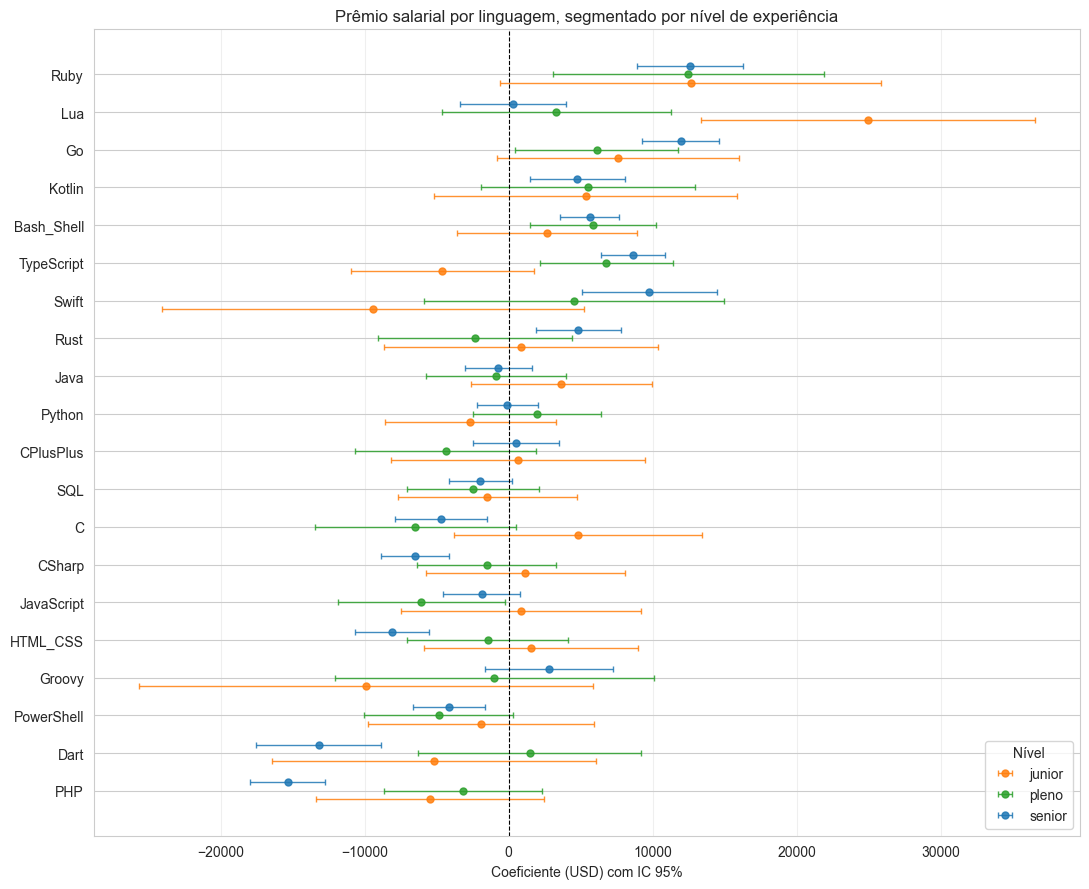

Salvo: output/figures/05_coefs_linguagens_por_nivel.png


In [11]:
linhas = []
for nivel in niveis:
    coefs = resultados_nivel[nivel]['coefs']
    for lang in linguagens:
        if lang in coefs.index:
            linhas.append({
                'linguagem': lang.replace('lang_', ''),
                'nivel':     nivel,
                'coef':      coefs.loc[lang, 'coef'],
                'ic_inf':    coefs.loc[lang, 'ic_inf'],
                'ic_sup':    coefs.loc[lang, 'ic_sup'],
            })

df_plot = pd.DataFrame(linhas)

ordem = (df_plot.groupby('linguagem')['coef']
         .mean().sort_values(ascending=True).index.tolist())

fig, ax = plt.subplots(figsize=(11, 9))
cores_nivel = {'junior': '#ff7f0e', 'pleno': '#2ca02c', 'senior': '#1f77b4'}
offsets = {'junior': -0.22, 'pleno': 0.0, 'senior': +0.22}

for nivel in niveis:
    sub = df_plot[df_plot['nivel'] == nivel].set_index('linguagem').loc[ordem]
    y = np.arange(len(ordem)) + offsets[nivel]
    ax.errorbar(
        sub['coef'], y,
        xerr=[sub['coef'] - sub['ic_inf'], sub['ic_sup'] - sub['coef']],
        fmt='o', color=cores_nivel[nivel], label=nivel, markersize=5,
        capsize=2, elinewidth=1, alpha=0.85,
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(np.arange(len(ordem)))
ax.set_yticklabels(ordem)
ax.set_xlabel('Coeficiente (USD) com IC 95%')
ax.set_title('Prêmio salarial por linguagem, segmentado por nível de experiência')
ax.legend(title='Nível', loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/figures/05_coefs_linguagens_por_nivel.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Salvo: output/figures/05_coefs_linguagens_por_nivel.png")

## 6. Conclusões do Notebook 05

A análise segmentada permite responder às três subperguntas da
pesquisa de forma estruturada:

**1. Quais linguagens pagam mais por área de atuação?**
Go, Ruby, TypeScript, Swift e Rust apresentam prêmio salarial
positivo nas quatro áreas analisadas (backend, frontend, fullstack,
mobile), com pequenas variações de magnitude. PHP, Dart, PowerShell e
HTML/CSS apresentam penalidade consistente em todas as áreas. Algumas
linguagens trocam de sinal entre áreas (Python é prêmio em backend e
penalidade em frontend), refletindo a especialização típica dos
mercados.

**2. Quais linguagens pagam mais no Brasil vs. contexto global?**
O mercado brasileiro destaca-se por valorizar Ruby (+USD 22.436, o
maior entre os seis países analisados) e Bash/Shell (+USD 10.384,
também o maior). JavaScript apresenta a maior penalidade no Brasil
entre os países comparados, comportamento oposto ao observado em
mercados europeus.

**3. Como o prêmio salarial varia com a experiência?**
TypeScript, Swift e Go pagam progressivamente mais conforme a
senioridade aumenta. Ruby mantém prêmio estável (~+USD 12.500) em
todos os níveis. PHP e Dart apresentam penalidade que se aprofunda
com a experiência, sugerindo concentração de sêniores nessas
linguagens em posições de manutenção de legado.

**Linguagens consistentemente bem pagas em todos os recortes:**
Go, Ruby, TypeScript, Bash/Shell e Kotlin aparecem com prêmio
positivo na maioria dos recortes feitos.

**Linguagens consistentemente penalizadas:** PHP e PowerShell
aparecem com coeficiente negativo em praticamente todos os recortes.

**Limitações do trabalho:**
- Os coeficientes refletem **associação**, não causalidade. Aprender
  uma linguagem específica não garante o aumento salarial associado
  a ela; o coeficiente reflete o perfil completo de quem a declara.
- Subamostras menores (mobile, Brasil, júnior) têm estimativas com
  maior incerteza. Comparações que envolvam esses grupos devem ser
  feitas com cautela.
- A amostra do Stack Overflow tende a sobrerrepresentar
  desenvolvedores experientes e mercados anglófonos, o que pode
  enviesar conclusões sobre o mercado global como um todo.